# 🏡 Villa Vente — Pipeline v2 (Corrigé)

**Corrections vs v1 (R²=0.56) :**
- ❌ `category_encoders.TargetEncoder` supprimé → causait du **data leakage**
- ❌ `surface_terrain_text` supprimé → disponible pour 3% seulement (bruit)
- ✅ Groupby features calculées dans `split_and_encode()` sur train uniquement
- ✅ CV calculée sur `X_train` (pas X_test)
- ✅ Pipeline step nommé `'preprocessor'` (cohérence evaluate/plot)
- ✅ `predict_price()` reçoit `stats` en argument

## 0. Imports

In [1]:
import os, sys, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from datetime import datetime
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PIPELINE_DIR = os.path.abspath("../../pipeline")
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

RAW_PATH   = "../../data/marrakech_immo_vente/villa_vente.csv"
CLEAN_PATH = "../../data/cleaned_data/vente/villa_vente_final.csv"
MODEL_PATH = "../../model_training/models/xgb_villa_vente.pkl"
META_PATH  = "../../model_training/models/xgb_villa_vente_metadata.json"
print("✅ Imports OK")


/home/nouhayla/Desktop/stage/gateone-deploy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


## 1. Chargement & Cleaning

In [2]:
from pip_villa import (
    load_data, split_and_encode, build_pipeline, train,
    evaluate, plot_results, predict_price,
    NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES, TARGET_LOG
)

df = load_data(RAW_PATH)
print(f"\nLocalisation_fine (top 15) :")
print(df["localisation_fine"].value_counts().head(15))
print(f"\ncat_surface :")
print(df["cat_surface"].value_counts())


Brut : (5036, 34)
Après dédup contenu : (4721, 34)
EUR → MAD : 282 lignes
✅ Shape finale : (3228, 55)
   Prix médian  : 5,250,000 MAD
   Zones        : 53

Localisation_fine (top 15) :
localisation_fine
autre_zone             355
route de l'ourika      311
targa                  281
marrakech              217
hay targa              166
amelkis                159
route d'ourika         157
route de ouarzazate    142
route amizmiz          135
route de tahanaout     113
agdal                   97
route de tahanaoute     78
route de fez            76
autre secteur           73
palmeraie               70
Name: count, dtype: int64

cat_surface :
cat_surface
medium    921
small     915
large     614
xlarge    357
tiny      342
estate     79
Name: count, dtype: int64


## 2. EDA

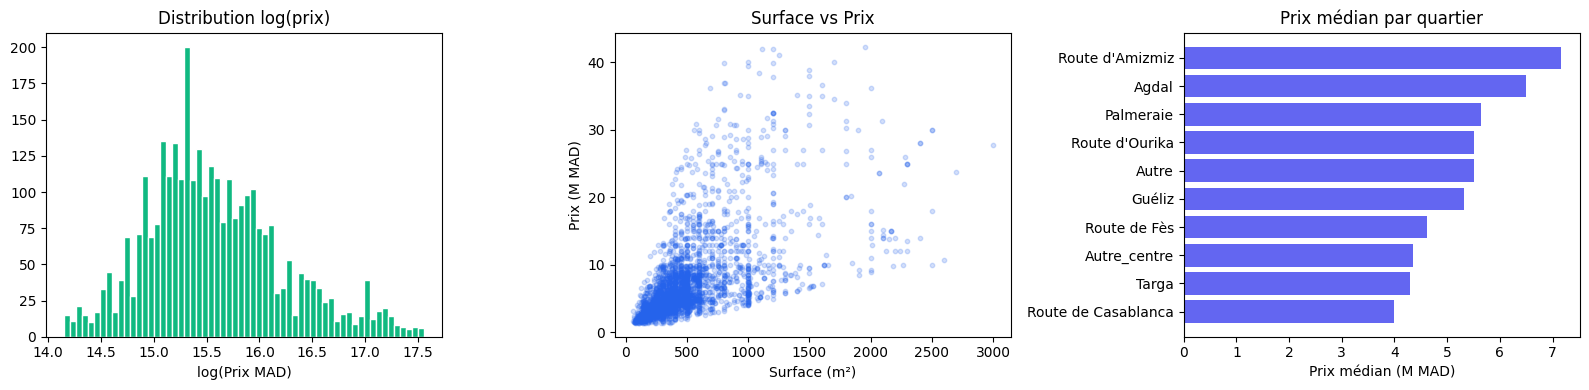


=== Corrélation features → log(prix) ===
surface_num            0.624
salles_bain_num        0.300
chambres_num           0.288
text_standing_score    0.287
kw_standing            0.232
kw_architecte          0.185
score_standing         0.152
nb_equipements         0.101
Name: log_prix, dtype: float64

=== Prix médian par quartier ===
                        median  count
quartier_clean                       
Route d'Amizmiz      7162610.0    173
Agdal                6500000.0    103
Palmeraie            5650000.0    127
Autre                5500000.0   1599
Route d'Ourika       5500000.0    517
Guéliz               5327500.0     30
Route de Fès         4620000.0    105
Autre_centre         4350000.0     54
Targa                4300000.0    461
Route de Casablanca  4000000.0     59


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0].set_title("Distribution log(prix)"); axes[0].set_xlabel("log(Prix MAD)")

axes[1].scatter(df["surface_num"], df["prix_num"]/1e6, alpha=0.2, s=10, color="#2563EB")
axes[1].set_xlabel("Surface (m²)"); axes[1].set_ylabel("Prix (M MAD)")
axes[1].set_title("Surface vs Prix")

med = df.groupby("quartier_clean")["prix_num"].median().sort_values(ascending=True)/1e6
axes[2].barh(med.index, med.values, color="#6366F1")
axes[2].set_xlabel("Prix médian (M MAD)"); axes[2].set_title("Prix médian par quartier")

plt.tight_layout(); plt.show()

print("\n=== Corrélation features → log(prix) ===")
num_check = ["surface_num","chambres_num","salles_bain_num","score_standing",
             "nb_equipements","text_standing_score","kw_standing","kw_architecte"]
print(df[num_check + ["log_prix"]].corr()["log_prix"].drop("log_prix")
      .sort_values(ascending=False).round(3))

print("\n=== Prix médian par quartier ===")
print(df.groupby("quartier_clean")["prix_num"]
      .agg(["median","count"]).sort_values("median",ascending=False).round(0))


## 3. Split + Groupby sans leakage

In [4]:
X_train, X_test, y_train, y_test, df_train, df_test, stats = split_and_encode(
    df, test_size=0.2, random_state=42
)
print(f"\nFeatures ({len(NUMERIC_FEATURES+BINARY_FEATURES+CATEGORICAL_FEATURES)}) :")
print(f"  Numériques   ({len(NUMERIC_FEATURES)}) : {NUMERIC_FEATURES[:5]}...")
print(f"  Binaires     ({len(BINARY_FEATURES)}) : {BINARY_FEATURES[:5]}...")
print(f"  Catégoriels  ({len(CATEGORICAL_FEATURES)}) : {CATEGORICAL_FEATURES}")


✅ Split — Train : 2582 | Test : 646 | Features : 46

Features (46) :
  Numériques   (29) : ['surface_num', 'log_surface', 'surface_par_chambre', 'ratio_ch_surface', 'chambres_num']...
  Binaires     (13) : ['piscine', 'parking', 'ascenseur', 'terrasse', 'jardin']...
  Catégoriels  (4) : ['quartier_clean', 'localisation_fine', 'cat_surface', 'segment_prix']


## 4. Baseline

In [5]:
pipeline_baseline = build_pipeline(X_train)
pipeline_baseline = train(pipeline_baseline, X_train, y_train)
metrics_baseline  = evaluate(pipeline_baseline, X_test, y_test, X_train, y_train)


✅ Pipeline — num:29 bin:13 cat:4
✅ Entraînement terminé (cible = log prix)

═════════════════════════════════════════════
  MÉTRIQUES — VILLA VENTE v2
═════════════════════════════════════════════
  MAE              :       1,243,950 MAD
  RMSE             :       2,075,567 MAD
  R²               :          0.8701
  MAPE             :          16.70 %
  CV R² (5 folds)  : 0.8856 ± 0.0094
═════════════════════════════════════════════


## 5. Optuna — 150 trials

> ⏱️ ~4-6 minutes

In [6]:
num_cols = [c for c in NUMERIC_FEATURES    if c in X_train.columns]
bin_cols = [c for c in BINARY_FEATURES     if c in X_train.columns]
cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train.columns]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              num_cols),
    ("bin", "passthrough",                                                 bin_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),   cat_cols),
], remainder="drop")
preprocessor.fit(X_train)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 500, 3000),
        learning_rate     = trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        max_depth         = trial.suggest_int("max_depth", 3, 8),
        max_leaves        = trial.suggest_int("max_leaves", 8, 63),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 3, 15),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        gamma             = trial.suggest_float("gamma", 0, 5),
        tree_method       = "hist",
    )
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params, random_state=42, n_jobs=-1)),
    ])
    # CV sur X_TRAIN — pas X_test
    return cross_val_score(
        pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1
    ).mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n✅ Meilleur R² CV : {study.best_value:.4f}")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


Best trial: 111. Best value: 0.889532: 100%|██████████| 150/150 [02:01<00:00,  1.23it/s]


✅ Meilleur R² CV : 0.8895
  n_estimators              : 593
  learning_rate             : 0.044461269324795466
  max_depth                 : 7
  max_leaves                : 21
  subsample                 : 0.8349105901729745
  colsample_bytree          : 0.8501917697235915
  colsample_bylevel         : 0.5042658243762241
  min_child_weight          : 12
  reg_alpha                 : 0.1018172557207982
  reg_lambda                : 0.0005688776687880534
  gamma                     : 0.10638078321921973


## 6. Modèle final

In [7]:
pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        **study.best_params, tree_method="hist", random_state=42, n_jobs=-1
    )),
])
pipeline_final.fit(X_train, y_train)
print("✅ Entraînement terminé")


✅ Entraînement terminé


## 7. Évaluation

In [8]:
metrics_final = evaluate(pipeline_final, X_test, y_test, X_train, y_train)

print(f"\n=== Gain vs baseline ===")
print(f"  R²   : {metrics_baseline['R²']:.4f} → {metrics_final['R²']:.4f}")
print(f"  MAPE : {metrics_baseline['MAPE (%)']:.2f}% → {metrics_final['MAPE (%)']:.2f}%")



═════════════════════════════════════════════
  MÉTRIQUES — VILLA VENTE v2
═════════════════════════════════════════════
  MAE              :       1,274,941 MAD
  RMSE             :       2,114,300 MAD
  R²               :          0.8653
  MAPE             :          17.02 %
  CV R² (5 folds)  : 0.8869 ± 0.0096
═════════════════════════════════════════════

=== Gain vs baseline ===
  R²   : 0.8701 → 0.8653
  MAPE : 16.70% → 17.02%


## 8. Visualisations

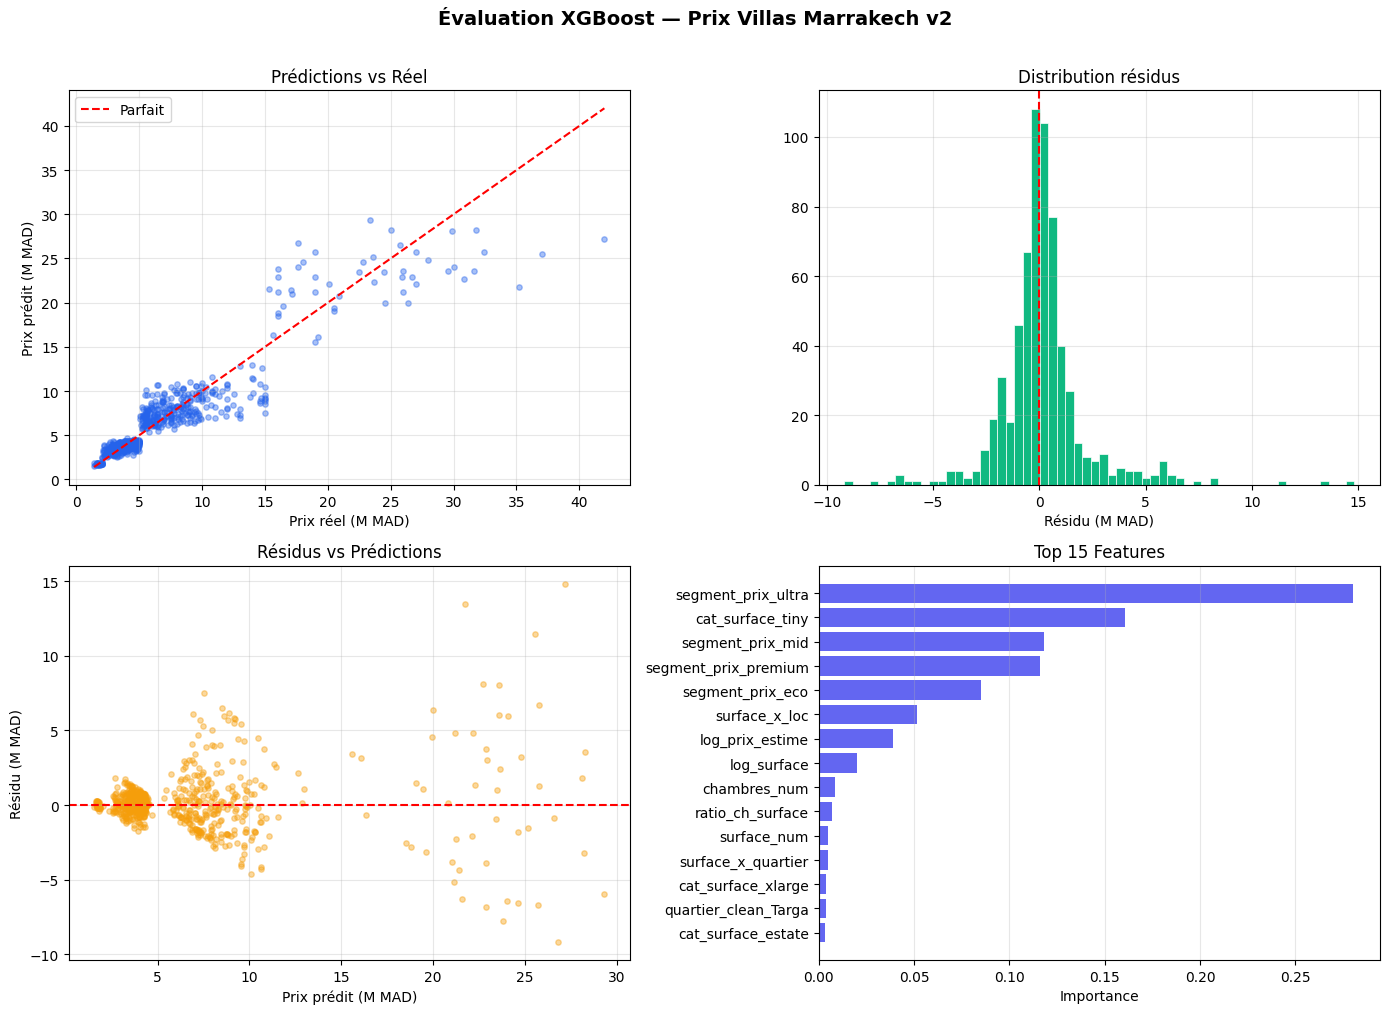

📊 villa_model_v2_evaluation.png


In [9]:
plot_results(pipeline_final, X_test, y_test)


## 9. Analyse erreurs

In [10]:
y_pred_mad = np.exp(pipeline_final.predict(X_test))
y_true_mad = np.exp(y_test.values)
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100

df_err = X_test.copy()
df_err["prix_reel"]   = y_true_mad
df_err["prix_predit"] = y_pred_mad
df_err["erreur_pct"]  = erreur_pct

print("=== MAPE par quartier ===")
print(df_err.groupby("quartier_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== MAPE par cat_surface ===")
print(df_err.groupby("cat_surface")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean",ascending=False).round(1))

print("\n=== Précision par seuil ===")
for s in [10, 20, 30, 50]:
    print(f"  Erreur <= {s:2d}% : {(erreur_pct<=s).mean()*100:.1f}% des cas")

print("\n=== Top 10 pires prédictions ===")
df_err["surface"] = df_train.loc[X_test.index.intersection(df_train.index), "surface_num"] if hasattr(df_train, 'loc') else 0
print(df_err.nlargest(10, "erreur_pct")[
    ["quartier_clean","localisation_fine","cat_surface","prix_reel","prix_predit","erreur_pct"]
].to_string())


=== MAPE par quartier ===
                     mean  count
quartier_clean                  
Route de Fès         19.4     18
Route d'Amizmiz      19.0     40
Autre                18.3    317
Guéliz               17.7      7
Agdal                17.6     26
Route d'Ourika       15.7    107
Palmeraie            14.6     22
Targa                14.1     86
Autre_centre         12.4     12
Route de Casablanca  10.6     11

=== MAPE par cat_surface ===
             mean  count
cat_surface             
xlarge       18.7     73
large        18.6    120
medium       17.8    190
small        15.7    169
estate       15.0     15
tiny         14.4     79

=== Précision par seuil ===
  Erreur <= 10% : 37.3% des cas
  Erreur <= 20% : 67.6% des cas
  Erreur <= 30% : 82.8% des cas
  Erreur <= 50% : 97.4% des cas

=== Top 10 pires prédictions ===
       quartier_clean    localisation_fine cat_surface  prix_reel  prix_predit  erreur_pct
4638            Autre            bab atlas      xlarge  5500000.0 

In [11]:
# ── Diagnostic features ─────────────────────────────────────
import numpy as np
import pandas as pd

xgb_model = pipeline_final.named_steps["model"]
preproc   = pipeline_final.named_steps["preprocessor"]

try:
    num_bin_cols = list(preproc.transformers_[0][2]) + list(preproc.transformers_[1][2])
    cat_cols_enc = list(preproc.named_transformers_["cat"].get_feature_names_out(
                        preproc.transformers_[2][2]))
    feat_names = num_bin_cols + cat_cols_enc
except:
    feat_names = [f"f{i}" for i in range(xgb_model.n_features_in_)]

importances = xgb_model.feature_importances_
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

print("=== Top 20 importances ===")
print(imp_df.head(20).to_string(index=False))

print("\n=== Nouvelles features — importance ===")
new_feats = ["log_surface","surf_x_piscine","surf_x_standing",
             "te_log_prix_quartier","te_log_prix_loc",
             "pm2_moy_quartier","pm2_median_loc"]
for f in new_feats:
    row = imp_df[imp_df["feature"] == f]
    imp = row["importance"].values[0] if len(row) else 0
    rank = imp_df[imp_df["feature"] == f].index[0] if len(row) else -1
    print(f"  {f:30s} imp={imp:.4f}")

# Corrélation nouvelles features → log_prix
print("\n=== Corrélation → log_prix (train) ===")
new_cols = [c for c in new_feats if c in X_train.columns]
corr = X_train[new_cols].corrwith(y_train).sort_values(ascending=False)
print(corr.round(3))

# Distribution target encoding
print("\n=== te_log_prix_quartier — distribution ===")
print(X_train["te_log_prix_quartier"].describe().round(3))
print(f"  NaN : {X_train['te_log_prix_quartier'].isna().sum()}")

# R² par quartier
y_pred = pipeline_final.predict(X_test)
df_diag = X_test.copy()
df_diag["y_true"] = y_test.values
df_diag["y_pred"] = y_pred
df_diag["residu"] = df_diag["y_true"] - df_diag["y_pred"]
print("\n=== Résidu moyen log_prix par quartier ===")
print(df_diag.groupby("quartier_clean")["residu"]
      .agg(["mean","std","count"]).round(3)
      .sort_values("mean", ascending=False))

=== Top 20 importances ===
             feature  importance
  segment_prix_ultra    0.280355
    cat_surface_tiny    0.160758
    segment_prix_mid    0.117969
segment_prix_premium    0.116254
    segment_prix_eco    0.084973
       surface_x_loc    0.051469
     log_prix_estime    0.039164
         log_surface    0.020128
        chambres_num    0.008737
    ratio_ch_surface    0.007054
         surface_num    0.005121
  surface_x_quartier    0.004675
  cat_surface_xlarge    0.003809
quartier_clean_Targa    0.003690
  cat_surface_estate    0.003374
     te_log_prix_loc    0.003135
           kw_jardin    0.003133
    surface_relative    0.002857
     salles_bain_num    0.002629
             piscine    0.002595

=== Nouvelles features — importance ===
  log_surface                    imp=0.0201
  surf_x_piscine                 imp=0.0016
  surf_x_standing                imp=0.0019
  te_log_prix_quartier           imp=0.0016
  te_log_prix_loc                imp=0.0031
  pm2_moy_quartier 

In [12]:
# ── Diagnostic plafond villa ─────────────────────────────────
import numpy as np
import pandas as pd

y_pred = pipeline_final.predict(X_test)
prix_pred = np.exp(y_pred)
prix_reel = np.exp(y_test.values)
erreur_pct = np.abs(prix_pred - prix_reel) / prix_reel * 100

df_diag = df_test.copy()
df_diag["erreur_pct"] = erreur_pct
df_diag["prix_pred"]  = prix_pred

# 1. Erreur par surface (tranches fines)
df_diag["surf_bin"] = pd.cut(df_diag["surface_num"],
    bins=[0,150,250,350,500,700,1000,9999],
    labels=["<150","150-250","250-350","350-500","500-700","700-1000",">1000"])
print("=== MAPE par tranche surface ===")
print(df_diag.groupby("surf_bin", observed=True)["erreur_pct"]
      .agg(["mean","count"]).round(1))

# 2. Erreur par tranche prix réel
df_diag["prix_bin"] = pd.cut(df_diag["prix_num"]/1e6,
    bins=[0,2,3,5,8,15,100],
    labels=["<2M","2-3M","3-5M","5-8M","8-15M",">15M"])
print("\n=== MAPE par tranche prix ===")
print(df_diag.groupby("prix_bin", observed=True)["erreur_pct"]
      .agg(["mean","count"]).round(1))

# 3. Corrélation résidu avec features — qu'est-ce qui reste non expliqué ?
df_diag["residu_log"] = y_test.values - y_pred
num_feats = [c for c in X_test.columns if X_test[c].dtype in [np.float64, np.int64]]
corr = X_test[num_feats].corrwith(pd.Series(df_diag["residu_log"].values,
                                             index=X_test.index))
print("\n=== Top corrélations résidu ~ features ===")
print(corr.abs().sort_values(ascending=False).head(15).round(3))

# 4. Combien de villas "Autre" ont une localisation_fine connue ?
autre_mask = df_test["quartier_clean"] == "Autre"
print(f"\n=== Villas 'Autre' ({autre_mask.sum()}) ===")
print(f"  localisation_fine != 'autre_zone' : "
      f"{(df_test.loc[autre_mask,'localisation_fine'] != 'autre_zone').sum()}")
print("  Top localisations fines :")
print(df_test.loc[autre_mask,"localisation_fine"].value_counts().head(10))

# 5. Variance intra-zone (log_prix) — plafond théorique par zone
print("\n=== Variance log_prix par quartier (std) ===")
print(df_train.groupby("quartier_clean")["log_prix"]
      .agg(["std","count"]).sort_values("std", ascending=False).round(3))

=== MAPE par tranche surface ===
          mean  count
surf_bin             
<150      13.1     38
150-250   15.9     97
250-350   15.4    113
350-500   17.8    190
500-700   17.6     91
700-1000  19.2     68
>1000     18.6     49

=== MAPE par tranche prix ===
          mean  count
prix_bin             
<2M       10.0     30
2-3M      24.5     64
3-5M      12.1    230
5-8M      21.3    155
8-15M     17.8    118
>15M      19.5     49

=== Top corrélations résidu ~ features ===
jardin                 0.130
text_standing_score    0.088
log_prix_estime        0.087
ratio_ch_surface       0.084
meuble                 0.083
kw_architecte          0.078
kw_jardin              0.078
kw_renove              0.077
surface_relative       0.077
pm2_median_loc         0.073
ascenseur              0.070
surface_x_loc          0.069
log_surface            0.069
surface_num            0.066
surface_x_quartier     0.065
dtype: float64

=== Villas 'Autre' (317) ===
  localisation_fine != 'autre_zone' : 

## 10. Sauvegarde

In [13]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# stats nécessaires pour predict_price()
joblib.dump({"pipeline": pipeline_final, "stats": stats}, MODEL_PATH)
print(f"✅ Modèle sauvegardé       → {MODEL_PATH}")

metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "version"        : "v2_optuna",
    "modele"         : "XGBRegressor",
    "type_bien"      : "villa_vente",
    "target"         : "log(prix_total)",
    "corrections_v2" : [
        "Suppression category_encoders (leakage)",
        "Suppression surface_terrain_text (3% coverage)",
        "Groupby features calculées sur train uniquement",
        "CV sur X_train (pas X_test)",
    ],
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : X_train.shape[1],
    "metriques_baseline": {
        "R2"  : round(metrics_baseline["R²"], 4),
        "MAPE": round(metrics_baseline["MAPE (%)"], 2),
    },
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"], 4),
        "MAE"  : round(metrics_final["MAE (MAD)"], 0),
        "RMSE" : round(metrics_final["RMSE (MAD)"], 0),
        "MAPE" : round(metrics_final["MAPE (%)"], 2),
    },
    "cv_r2_optuna"   : round(study.best_value, 4),
    "hyperparametres": study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"✅ Métadonnées sauvegardées → {META_PATH}")

df.to_csv(CLEAN_PATH, index=False)
print(f"✅ Dataset sauvegardé      → {CLEAN_PATH}")

print("\n" + "═"*50)
print("  RÉSUMÉ FINAL — VILLA VENTE v2")
print("═"*50)
print(f"  Données          : {len(df):,} villas")
print(f"  Features         : {X_train.shape[1]}")
print(f"  R² baseline      : {metrics_baseline['R²']:.4f}")
print(f"  R² final         : {metrics_final['R²']:.4f}")
print(f"  MAE              : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE             : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² Optuna     : {study.best_value:.4f}")
print("═"*50)


✅ Modèle sauvegardé       → ../../model_training/models/xgb_villa_vente.pkl
✅ Métadonnées sauvegardées → ../../model_training/models/xgb_villa_vente_metadata.json
✅ Dataset sauvegardé      → ../../data/cleaned_data/vente/villa_vente_final.csv

══════════════════════════════════════════════════
  RÉSUMÉ FINAL — VILLA VENTE v2
══════════════════════════════════════════════════
  Données          : 3,228 villas
  Features         : 46
  R² baseline      : 0.8701
  R² final         : 0.8653
  MAE              : 1,274,941 MAD
  MAPE             : 17.02 %
  CV R² Optuna     : 0.8895
══════════════════════════════════════════════════


## 11. Exemple de prédiction

In [14]:
saved           = joblib.load(MODEL_PATH)
pipeline_loaded = saved["pipeline"]
stats_loaded    = saved["stats"]

villa_exemple = {
    "surface_num"      : 450,
    "chambres_num"     : 5,
    "salles_bain_num"  : 3,
    "etage"            : 0,
    "etage_known"      : 1,
    "quartier_clean"   : "Palmeraie",
    "localisation_fine": "palmeraie",
    "cat_surface"      : "large",
    "piscine"    : 1, "parking"       : 1, "ascenseur" : 0,
    "terrasse"   : 1, "jardin"         : 1, "climatisation": 1,
    "securite"   : 1, "vue"            : 0, "meuble"    : 0,
    "neuf"       : 0, "cave"           : 0, "hammam"    : 1,
    "kw_standing": 1, "kw_renove"      : 0, "kw_architecte": 0,
    "kw_jardin"  : 1, "kw_projet"      : 0,
}

prix = predict_price(pipeline_loaded, villa_exemple, stats_loaded)
fourchette_min = prix * 0.75
fourchette_max = prix * 1.25
print(f"\n  Fourchette ±25% : {fourchette_min:,.0f} – {fourchette_max:,.0f} MAD")


💰 Villa 450 m² | Palmeraie | Prix estimé : 8,707,940 MAD (806,291 EUR)
   ≈ 19,351 MAD/m²

  Fourchette ±25% : 6,530,955 – 10,884,925 MAD
